In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.ndimage import gaussian_filter

In [2]:
colors = np.linspace(0, 1, 5)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=plt.cm.rainbow(colors))

os.makedirs("../img", exist_ok=True)

# Algorithm 1 Policy Iteration for Entropy-regularized Optimal Stopping (PI-λ-OS)

## Parameters

In [3]:
mu = 0.2
sigma = 0.2
rho = 0.5
kappa = 5.0
lambda_ = 0.2
theta = 0.5
zeta = 0.9
K = 20

In [4]:
def set_variant_parameters(variant: int) -> None:
    """
    Set the parameters for the specified variant.

    Parameters:
    variant: The variant number (1 or 2).
    """
    global Nx, Ny, x_max, x_grid, y_grid, dx, dy

    if variant == 1:
        Nx = 250
        Ny = 50
        x_max = 5
    else:
        Nx = 1000
        Ny = 1000
        x_max = 50

    x_grid = np.linspace(1e-4, x_max, Nx)
    y_grid = np.linspace(1e-4, 1.0, Ny)
    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]

## Algorithm functions

In [5]:
def pi(x: float) -> float:
    return x**theta

In [6]:
def build_matrix_and_rhs(g: np.ndarray) -> tuple:
    """
    Build the matrix A and the right-hand side vector b for the linear system.

    Parameters:
    g: The grid for the function g(x).

    Returns:
    The matrix A and the right-hand side vector b.
    """
    N = Nx * Ny
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return i * Ny + j

    for i in range(Nx):
        x = x_grid[i]

        for j in range(Ny):
            y = y_grid[j]
            k = idx(i, j)

            if j == 0:
                A[k, k] = 1
                b[k] = 0
                continue

            if y > g[i]:
                A[k, k] = 1
                A[k, idx(i, j - 1)] = -1
                b[k] = 0
                continue

            if i == 0:
                A[k, k] = -rho
                b[k] = -((pi(x) - rho * kappa) * y - lambda_ * y * np.log(y))
            elif i == Nx - 1:
                A[k, k] = 1
                A[k, idx(i - 1, j)] = -2
                A[k, idx(i - 2, j)] = 1
                b[k] = 0
            else:
                a = 0.5 * sigma**2 * x**2 / dx**2
                b1 = mu * x / (2 * dx)

                A[k, k] = -2 * a - rho

                if i > 0:
                    A[k, idx(i - 1, j)] = a - b1
                if i < Nx - 1:
                    A[k, idx(i + 1, j)] = a + b1

                rhs = (pi(x) - rho * kappa) * y - lambda_ * y * np.log(y)

                b[k] = -rhs

    return A.tocsr(), b

In [7]:
def solve_u(g: np.ndarray) -> np.ndarray:
    """
    Solve the linear system to find u given the grid g.
    Corresponds to line 3 in the algorithm from the article.

    Parameters:
    g (np.ndarray): The grid for the function g(x).

    Returns:
    The solution u reshaped to the grid dimensions (Nx, Ny).
    """
    A, b = build_matrix_and_rhs(g)

    u_vec = spla.spsolve(A, b)

    u = u_vec.reshape((Nx, Ny))

    return u

In [8]:
def policy_improvement(
    u: np.ndarray, g: np.ndarray, tolerance: float = 1e-5
) -> np.ndarray:
    """
    Perform policy improvement to update the boundary g based on the solution u.
    Corresponds to line 4 in the algorithm from the article.

    Parameters:
    u: The solution u obtained from the PDE solver.
    g: The current boundary g.
    tolerance: The threshold for determining significant changes in the second derivative.

    Returns:
    The updated boundary g after policy improvement.
    """
    g_new = g.copy()

    u_smooth = gaussian_filter(u, sigma=2.0)
    ux = np.gradient(u_smooth, dx, axis=0)
    uxy = np.gradient(ux, dy, axis=1)

    for i in range(Nx):
        j_boundary = np.argmin(np.abs(y_grid - g[i]))

        if uxy[i, j_boundary] < -tolerance:
            sign_change = np.where(np.diff(np.sign(uxy[i, :])))[0]
            valid = [j for j in sign_change if y_grid[j] < g[i]]

            if len(valid) > 0:
                g_new[i] = y_grid[max(valid)]

    return g_new

In [9]:
def policy_iteration(g0: np.ndarray, K: int = 10) -> tuple:
    """
    Perform policy iteration to find the optimal boundary g and the corresponding solution u.
    Corresponds to lines 1 and 2 in the algorithm from the article.

    Parameters:
    g0: The initial guess for the boundary g.
    K: The maximum number of iterations for policy iteration.

    Returns:
    A tuple containing:
    - gs: A list of g values at each iteration.
    - g: The final boundary g after convergence.
    - u: The solution u corresponding to the final boundary g.
    """
    g = g0()
    gs = [g.copy()]

    for k in range(K):
        u = solve_u(g)
        g = policy_improvement(u, g)

        gs.append(g.copy())

        if np.max(np.abs(g - gs[-2])) < 1e-32:
            print(f"Converged at iteration {k+1}")
            break

    return gs, g, u

## Examples of initialization functions

In [10]:
def func_g_true():
    g = np.zeros_like(x_grid)

    P = rho - theta * mu - (sigma**2) * theta * (theta - 1) / 2
    alfa = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)

    for i, x in enumerate(x_grid):
        g[i] = min(
            np.exp((rho / lambda_) * ((x**theta / P) * (1 - theta / alfa) - kappa) - 1),
            1.0,
        )

    return g

In [11]:
def func_linear():
    g = np.zeros_like(x_grid)
    base = np.exp(-(1 + kappa * rho / lambda_))
    alpha = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)

    x1 = 0.5 * (-alpha * (kappa + lambda_ / rho) / (theta - alpha)) ** (-theta)

    for i, x in enumerate(x_grid):
        g[i] = min(base + (1.0 - base) / x1 * x, 1.0)
    return g

In [12]:
def func_exponential():
    g = np.zeros_like(x_grid)

    P = rho - zeta * mu - (sigma**2) * zeta * (zeta - 1) / 2
    alfa = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)

    for i, x in enumerate(x_grid):
        g[i] = min(
            np.exp((rho / lambda_) * ((x**zeta / P) * (1 - zeta / alfa) - kappa) - 1),
            1.0,
        )
    return g

In [13]:
def func_proposed():
    base = np.exp(-(1 + kappa * rho / lambda_))
    g = np.zeros_like(x_grid)

    for i, x in enumerate(x_grid):
        g[i] = min(base + x**2, 1.0)

    return g

## Outcome functions

In [14]:
def plot_results(
    gs: list, g_final_0: np.ndarray, g_true_vals: np.ndarray, title: str
) -> None:
    """
    Plot the results of the policy iteration, including the true boundary, initial guess, K/2 iteration, and final boundary.

    Parameters:
    gs: A list of g values at each iteration.
    g_final_0: The final boundary g after convergence.
    g_true_vals: The true boundary values for comparison.
    title: The title for the plot.
    """
    K = len(gs) - 1

    plt.plot(
        x_grid,
        g_true_vals,
        color="gray",
        linestyle="--",
        linewidth=2,
        label="g_true (determined analytically)",
    )
    plt.plot(x_grid, gs[0], label="g_0(x)", linestyle="dashed", color="red")

    # Optional: plotting graphs for each iteration
    # for i in range(1, len(gs) - 1):
    #     plt.plot(x_grid, gs[i], alpha=0.4)

    # Graph for iteration K//2
    if K > 2:
        mid_k = K // 2
        plt.plot(
            x_grid, gs[mid_k], label=f"g(x) iter {mid_k}", color="orange", alpha=0.7
        )

    plt.plot(x_grid, g_final_0, label="g(x) final", linewidth=2, color="black")

    plt.xlabel("x")
    plt.ylabel("g(x)")
    plt.xlim(0, 6)
    plt.title(title)
    plt.grid(True)
    plt.legend()

In [15]:
def plot_L1_error(gs: list, dx: float) -> None:
    """
    Plot the L1 error of the policy iteration.

    Parameters:
    gs: A list of g values at each iteration.
    dx: The step size for the discretization.
    """
    g_true_vals = func_g_true()
    gs_ = gs[1:]

    l1_errors = []

    for g_iter in gs_:
        error = np.sum(np.abs(g_iter - g_true_vals)) * dx
        l1_errors.append(error)

    plt.plot(
        range(1, len(l1_errors) + 1), l1_errors, marker="o", linestyle="-", color="blue"
    )
    plt.title("Convergence to g_true in the L1 norm")
    plt.xlabel("iteration")
    plt.ylabel("L1 error")

    plt.xticks(np.arange(1, len(l1_errors) + 1, 2))

    plt.grid(True)

In [16]:
def find_hitting_point(
    g_array: np.ndarray, x_array: np.ndarray, threshold: float = 0.999
) -> float:
    """
    Find the x value where g_array first reaches or exceeds the threshold.

    Parameters:
    g_array: The array of g values.
    x_array: The corresponding x values.
    threshold: The threshold value to find the hitting point.

    Returns:
    The x value where g_array first reaches or exceeds the threshold. Returns NaN if the threshold is not reached.
    """
    idx = np.argmax(g_array >= threshold)
    if idx == 0 and g_array[0] < threshold:
        return np.nan
    return x_array[idx]

## Function that runs the algorithm for different variants

In [17]:
def run_algorithm_1(
    g0_func: callable, func_true: callable, K: int, title_prefix: str
) -> None:
    """
    Run the policy iteration algorithm for two variants and plot the results.

    Parameters:
    g0_func: A callable that returns the initial guess for g.
    func_true: A callable that returns the true g values for comparison.
    K: The maximum number of iterations for policy iteration.
    title_prefix: A string prefix for the plot titles.

    Variants:
    1: Parameters as proposed in the article.
    2: Parameters with a more refined grid for better results.
    """
    plt.figure(figsize=(18, 15))

    for variant in [1, 2]:
        print(f"Running calculations: {title_prefix} | Variant {variant}...")

        set_variant_parameters(variant)

        g_true_vals = func_true()
        true_hit_1 = find_hitting_point(g_true_vals, x_grid)

        gs, g_final, _ = policy_iteration(g0_func, K=K)

        # Calculating the L1 error
        l1_errors = [np.sum(np.abs(g_iter - g_true_vals)) * dx for g_iter in gs[1:]]
        final_l1 = l1_errors[-1]

        # Finding hitting point
        model_hit_1 = find_hitting_point(g_final, x_grid)

        # Plotting the boundary graph
        plt.subplot(2, 2, variant)
        plot_results(gs, g_final, g_true_vals, f"{title_prefix} | Variant {variant}")

        # Plotting the L1 error
        plt.subplot(2, 2, variant + 2)
        plt.plot(
            range(1, len(l1_errors) + 1),
            l1_errors,
            marker="o",
            linestyle="-",
            color="blue",
        )
        plt.title(f"{title_prefix} | L1 Error (Variant {variant})")
        plt.xlabel("Iteration")
        plt.ylabel("L1 error")
        plt.grid(True)

        # Log output
        print(f"--- RESULTS FOR VARIANT {variant} ---")
        print(f"Final L1 error:      {final_l1:.6f}")
        print(
            f"g_true reaches 1 at:    X = {true_hit_1:.4f}"
            if not np.isnan(true_hit_1)
            else "g_true does not reach 1."
        )
        print(
            f"Model reaches 1 at:     X = {model_hit_1:.4f}"
            if not np.isnan(model_hit_1)
            else "Model does not reach 1."
        )
        print("-" * 35)

    plt.tight_layout()

    filename = f"algorithm_1_{title_prefix.replace(' ', '_')}_results.png"
    save_path = os.path.join("../img", filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## Results

### analytical initialization

Running calculations: analytical initialization | Variant 1...
Converged at iteration 1
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      0.000000
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 4.3976
-----------------------------------
Running calculations: analytical initialization | Variant 2...
Converged at iteration 1
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.000000
g_true reaches 1 at:    X = 4.4045
Model reaches 1 at:     X = 4.4045
-----------------------------------


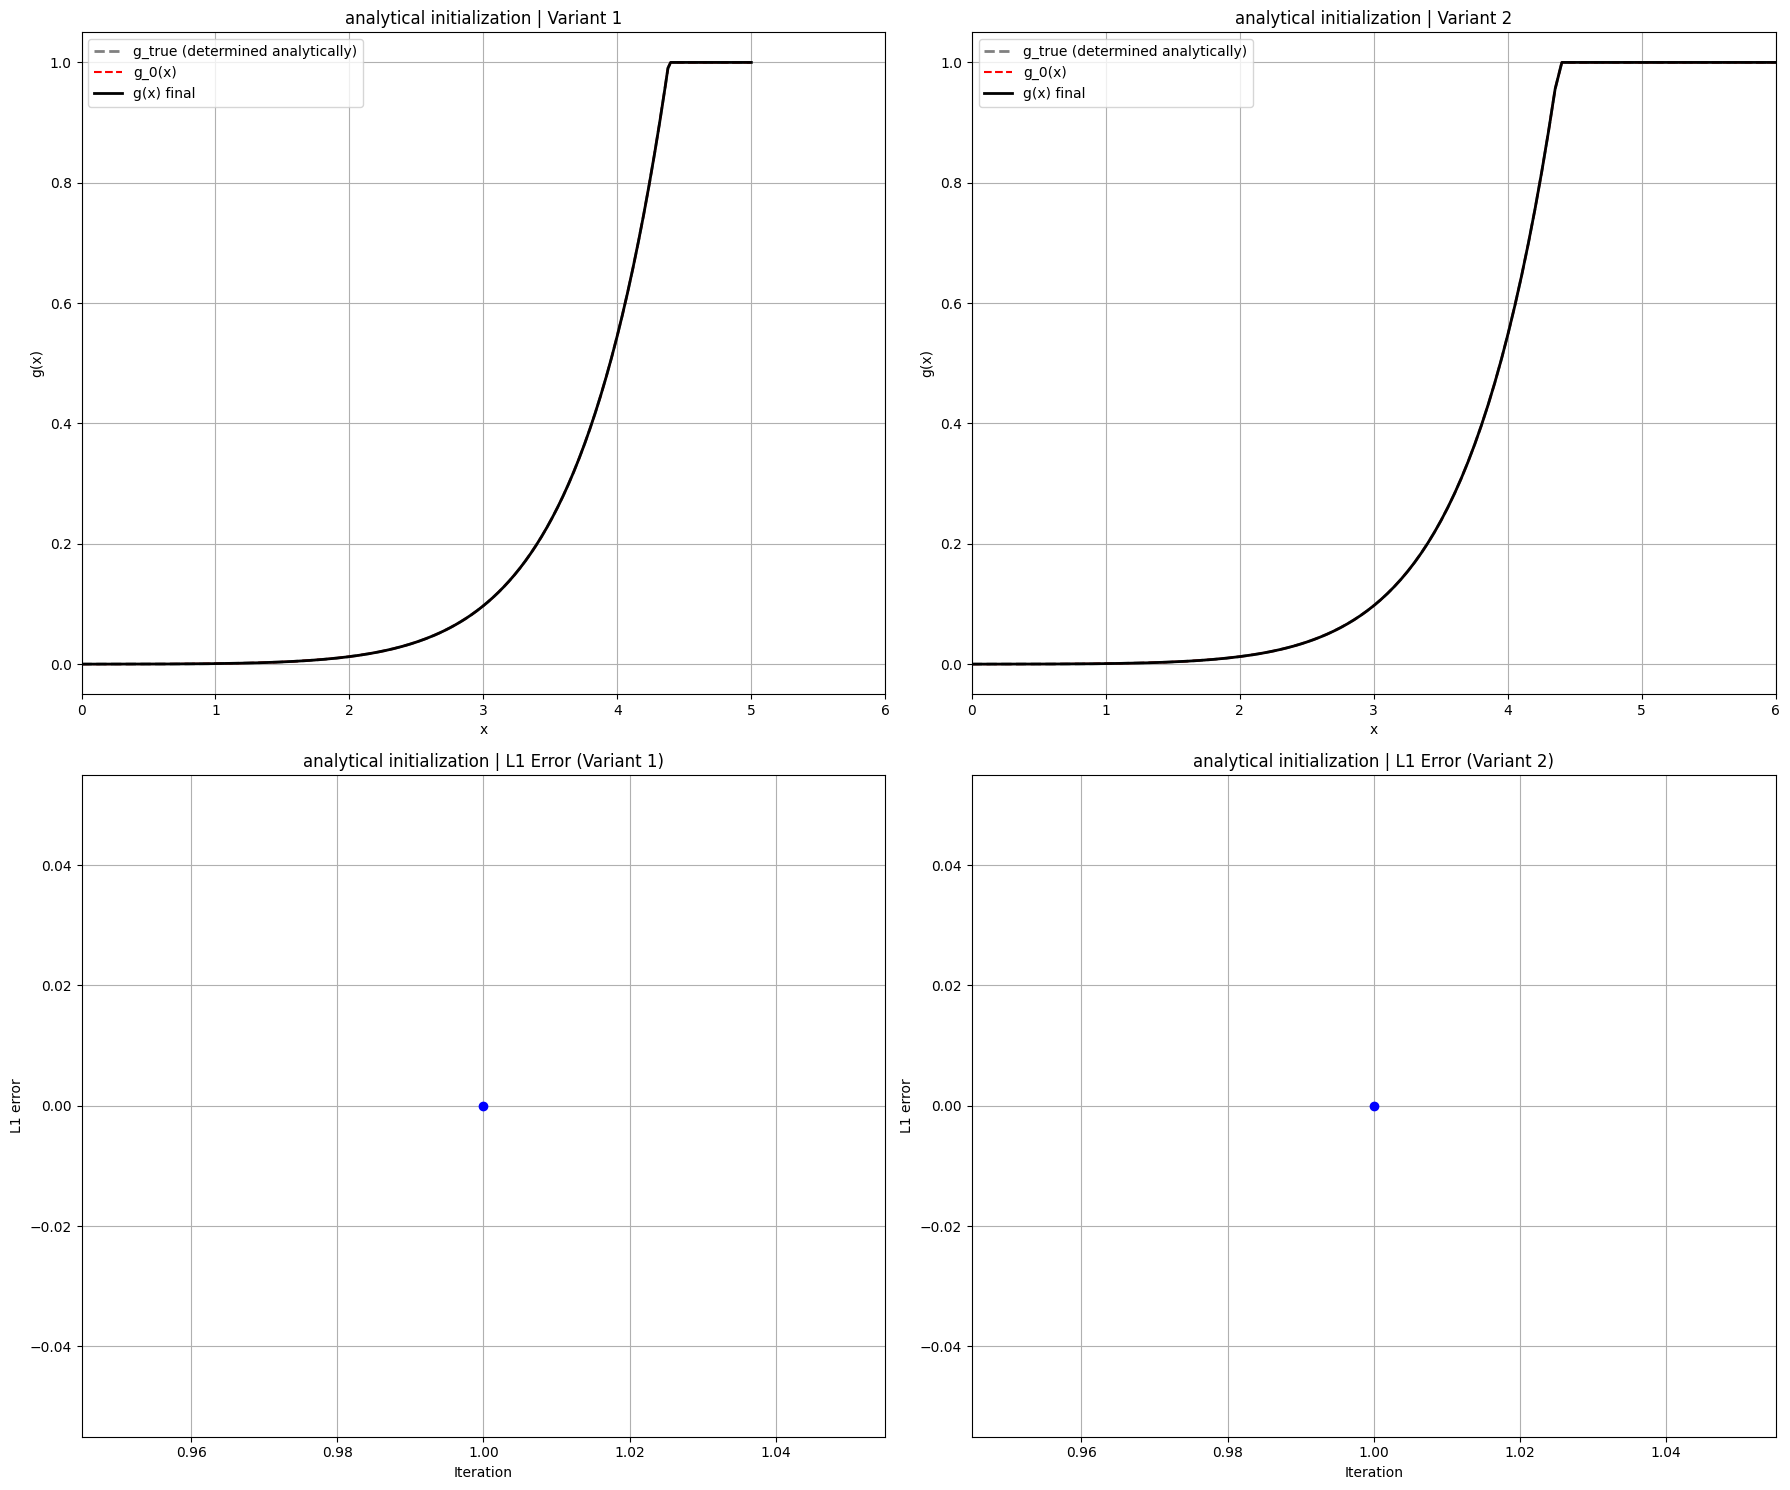

In [18]:
run_algorithm_1(func_g_true, func_g_true, K=K, title_prefix="analytical initialization")

### linear initialization

Running calculations: linear initialization | Variant 1...
Converged at iteration 16
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      0.477582
g_true reaches 1 at:    X = 4.3976
Model does not reach 1.
-----------------------------------
Running calculations: linear initialization | Variant 2...
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.223569
g_true reaches 1 at:    X = 4.4045
Model reaches 1 at:     X = 4.3544
-----------------------------------


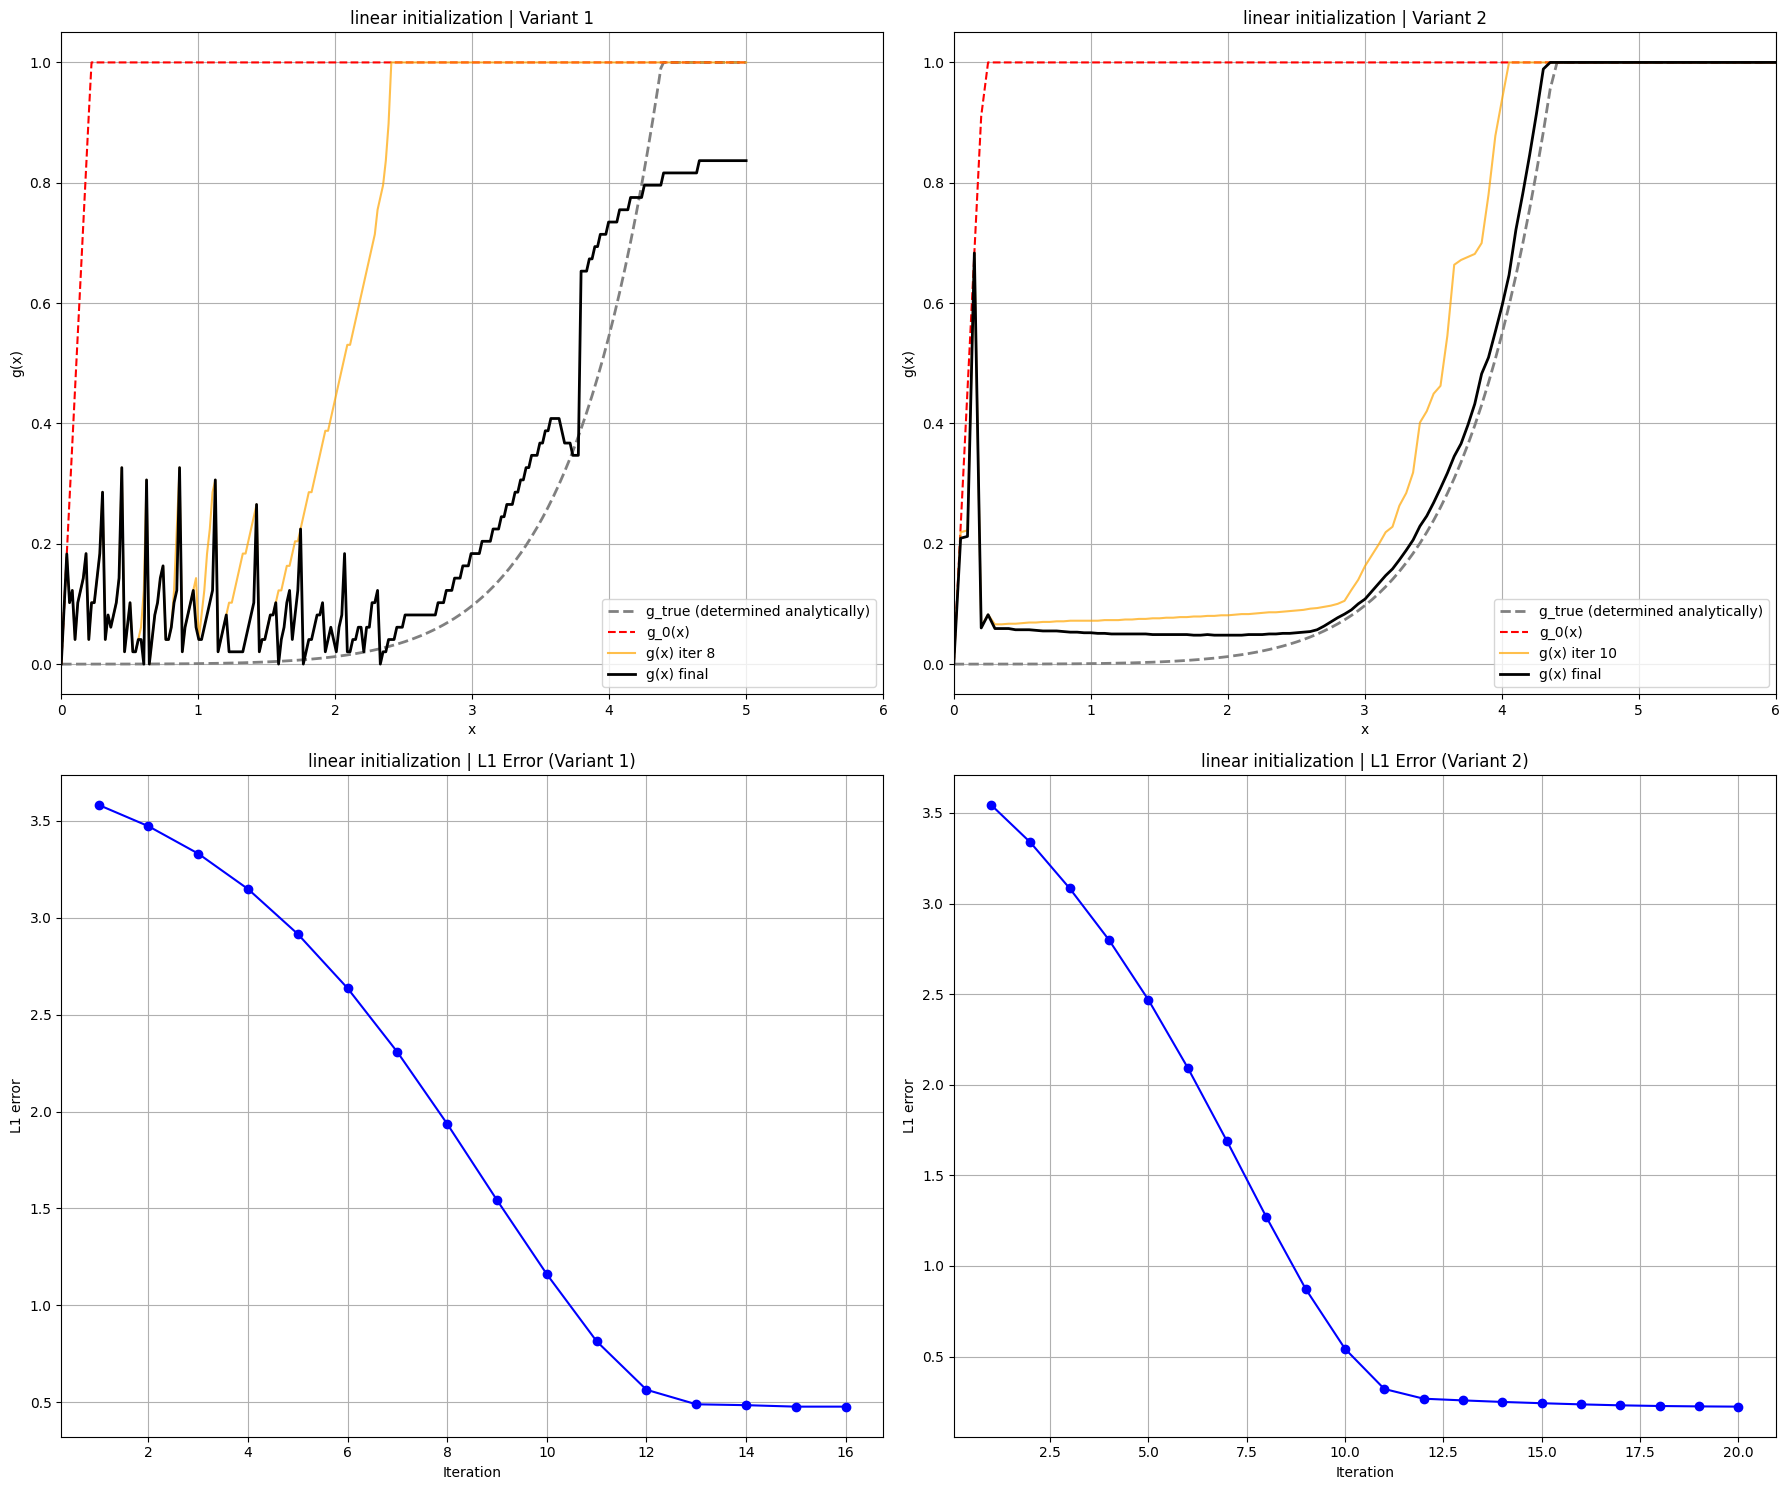

In [22]:
run_algorithm_1(func_linear, func_g_true, K=K, title_prefix="linear initialization")

### exponential initialization

Running calculations: exponential initialization | Variant 1...


Converged at iteration 11
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      0.369857
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 3.8554
-----------------------------------
Running calculations: exponential initialization | Variant 2...
Converged at iteration 8
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.064650
g_true reaches 1 at:    X = 4.4045
Model reaches 1 at:     X = 4.3544
-----------------------------------


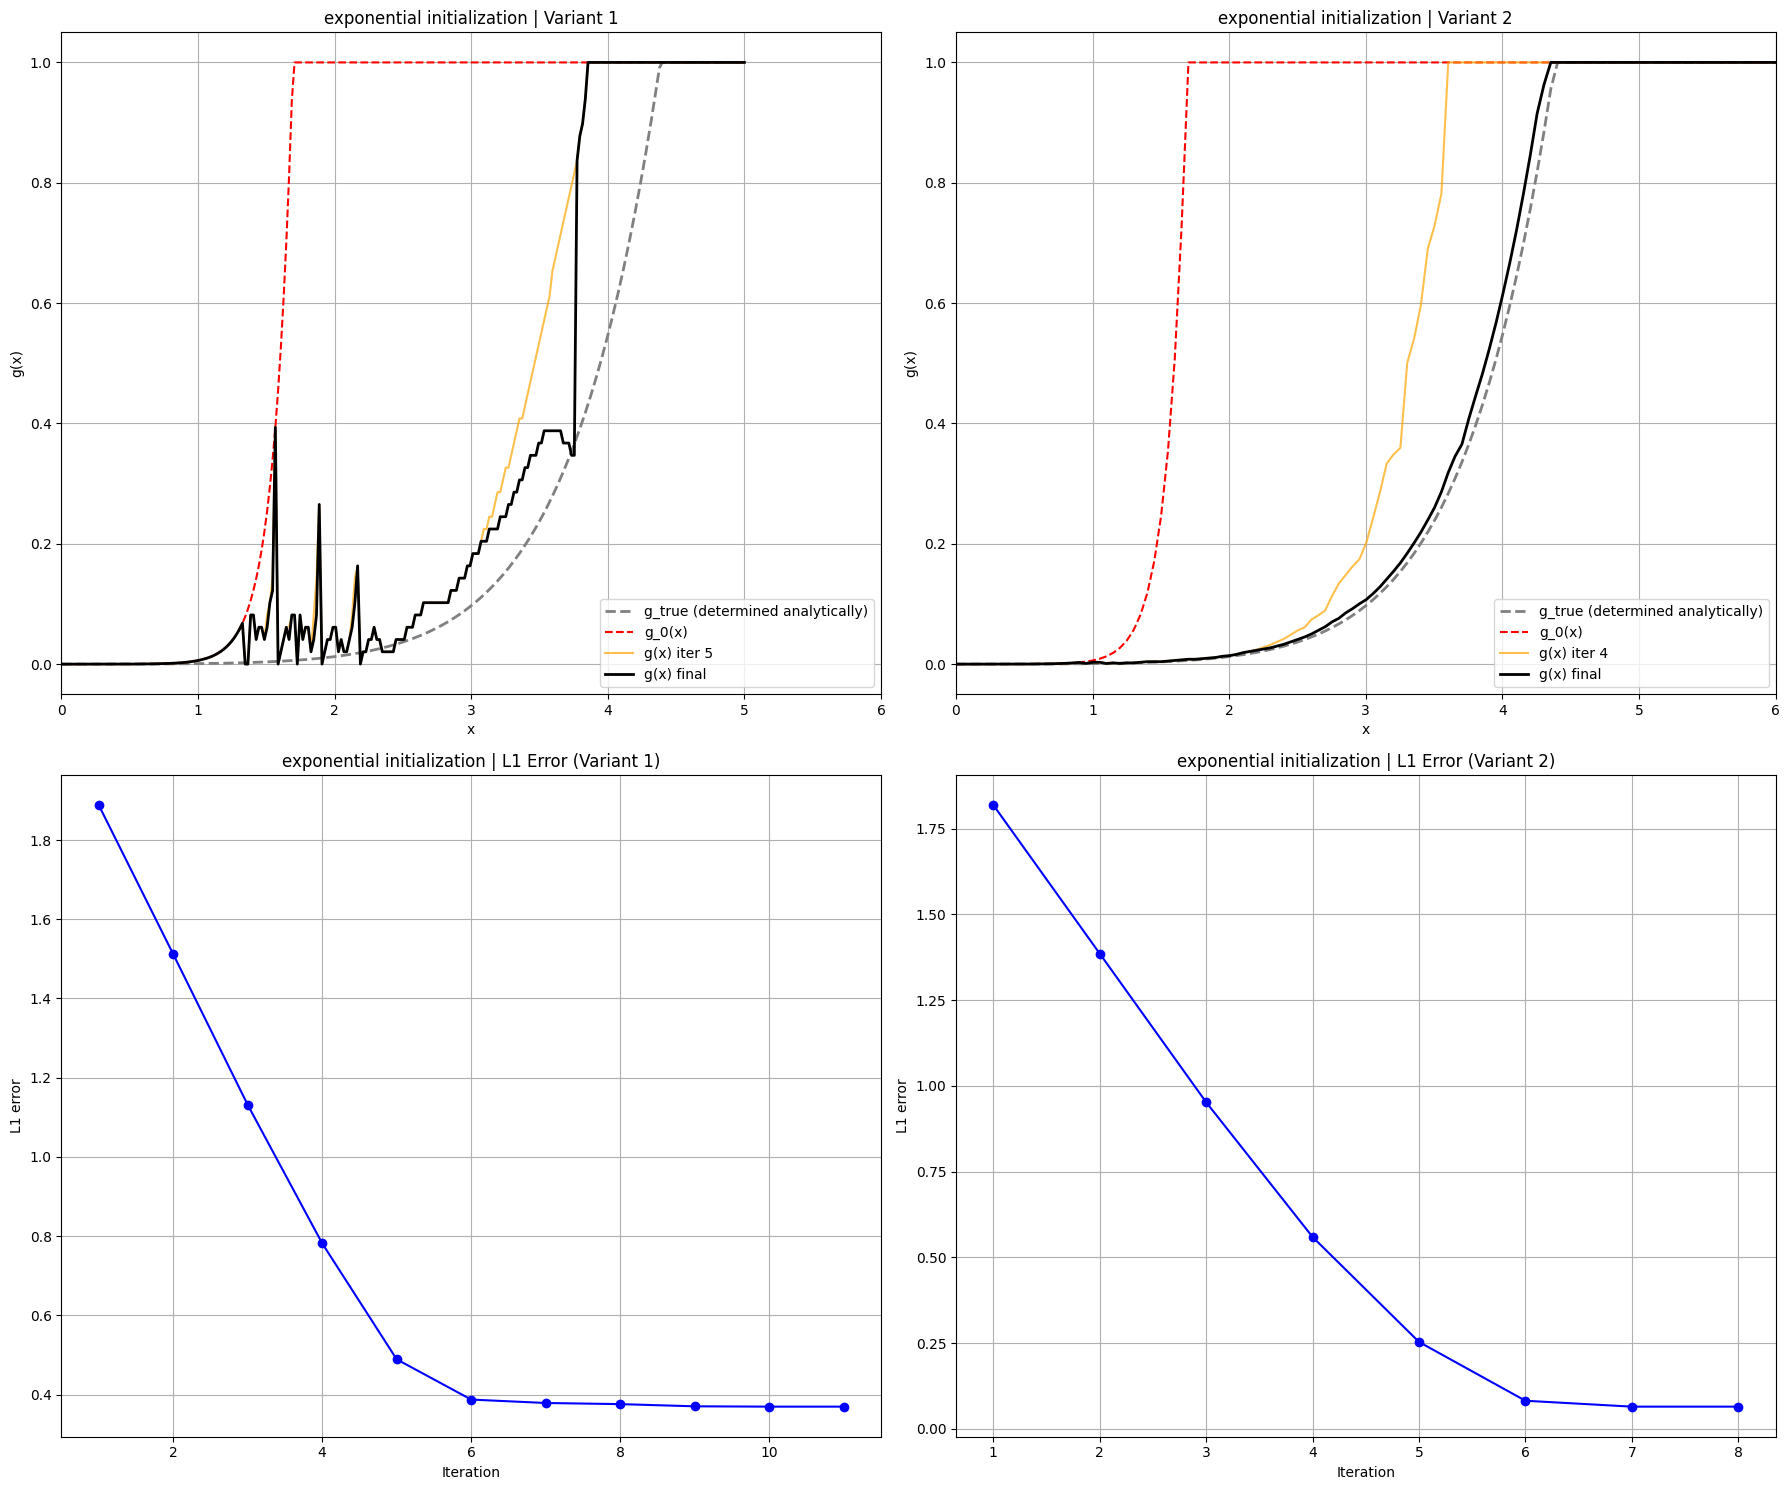

In [20]:
run_algorithm_1(
    func_exponential, func_g_true, K=K, title_prefix="exponential initialization"
)

### proposed initialization

Running calculations: proposed initialization | Variant 1...


Converged at iteration 12
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      0.440760
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 3.7751
-----------------------------------
Running calculations: proposed initialization | Variant 2...
Converged at iteration 11
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.066934
g_true reaches 1 at:    X = 4.4045
Model reaches 1 at:     X = 4.3544
-----------------------------------


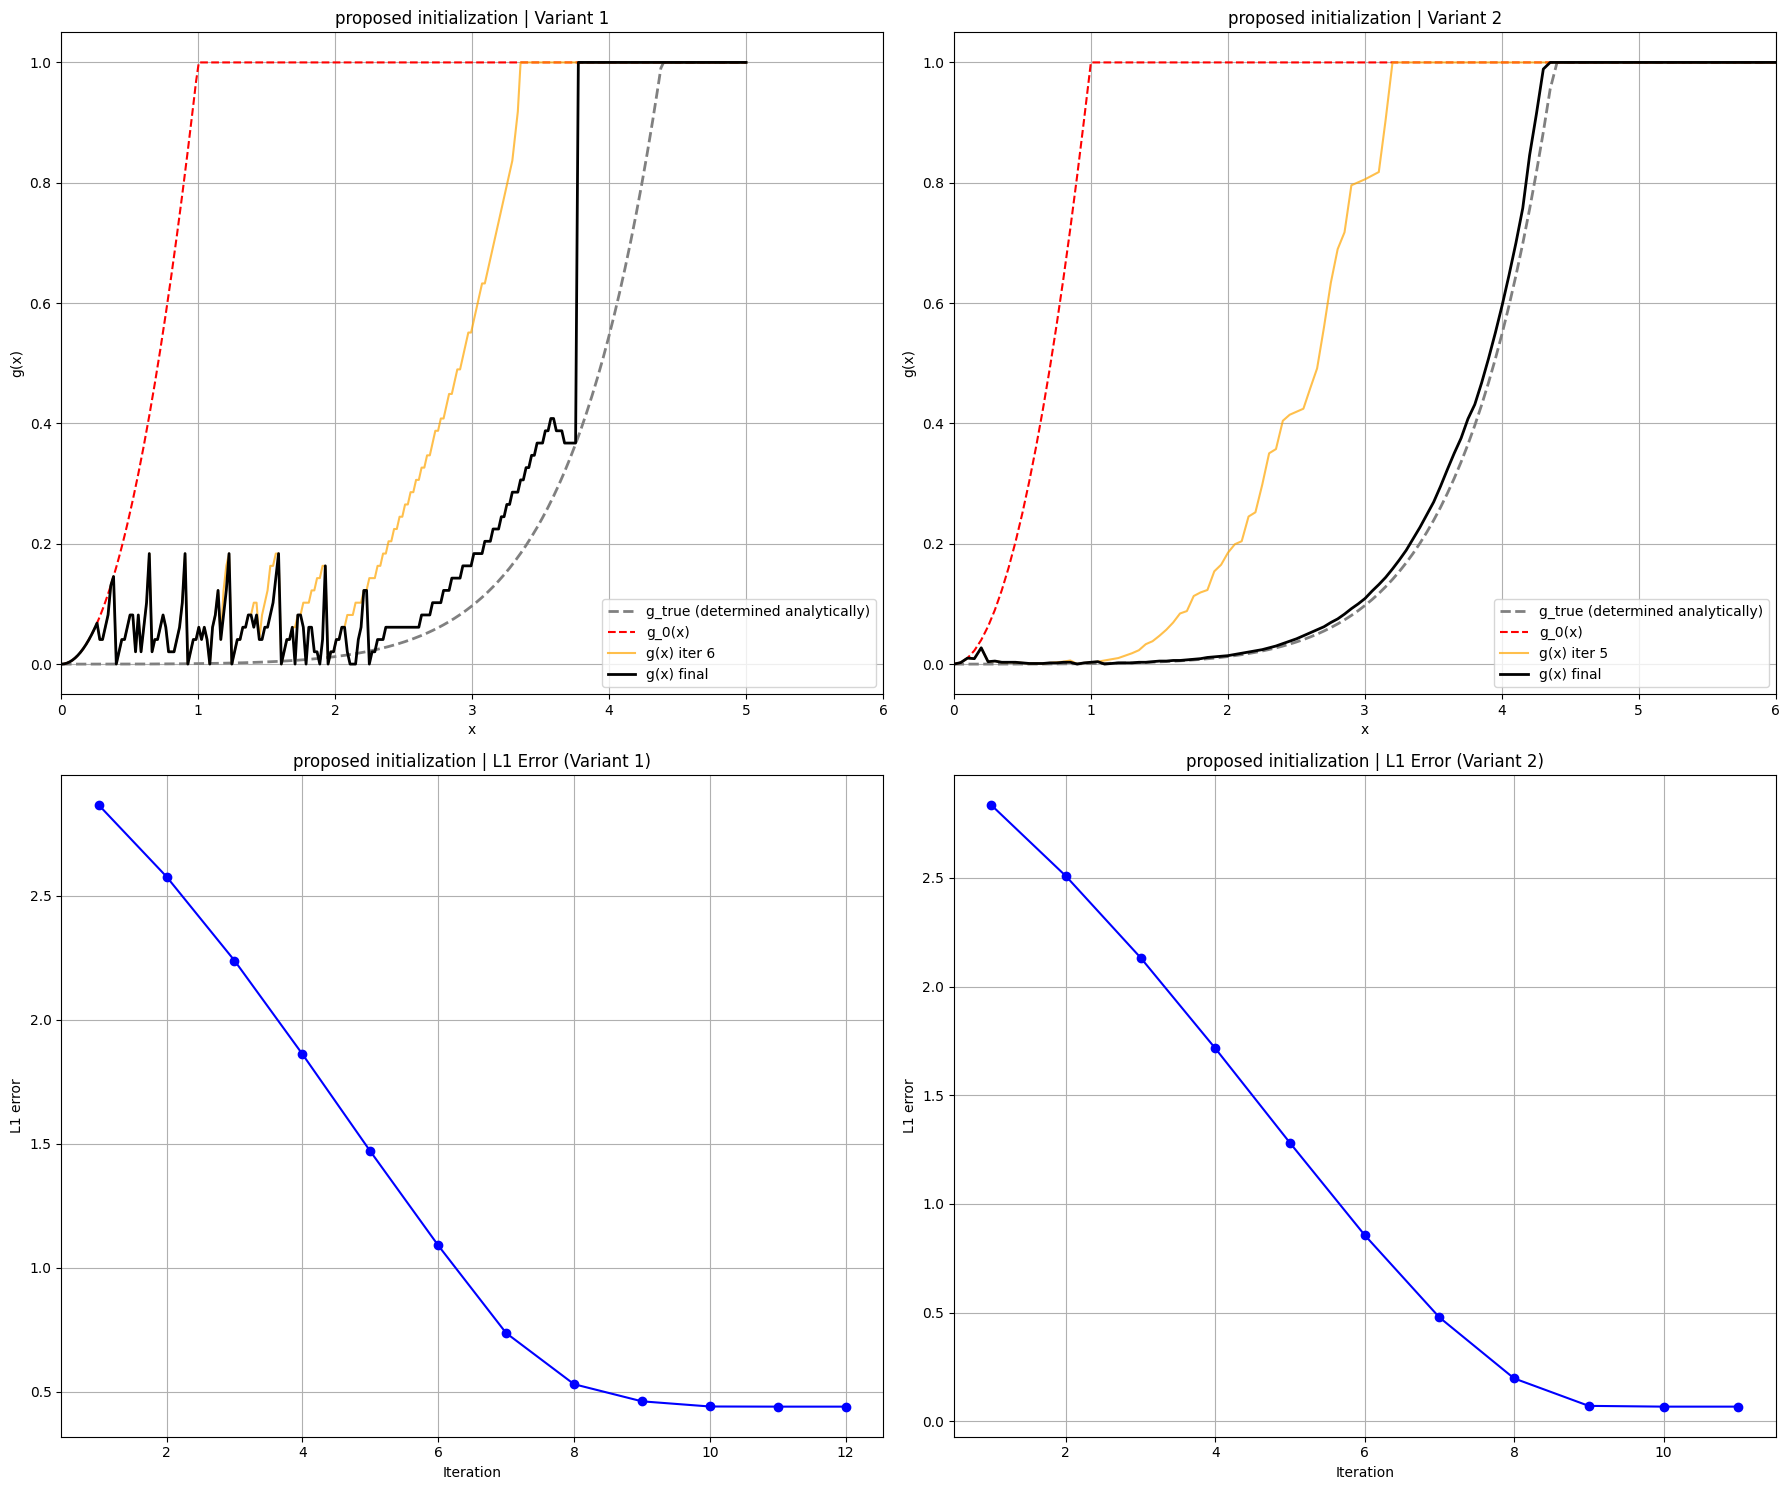

In [21]:
run_algorithm_1(func_proposed, func_g_true, K=K, title_prefix="proposed initialization")

## Conclusions

Based on the experiments conducted for the model-based Policy Iteration algorithm, we can draw the following key conclusions:

1. **Theoretical Consistency:** The algorithm successfully replicates the underlying mathematical theory. When initialized with the theoretical boundary (`analytical initialization`), the algorithm converges immediately (at iteration 1) with an $L_1$ error of $0.000000$, proving that the true boundary is indeed a fixed point of the HJB-based policy update operator.

2. **Impact of Grid Resolution:** The comparison between Variant 1 (coarse grid: $N_x=250$, $N_y=50$, $x_{max}=5$) and Variant 2 (fine grid: $N_x=1000$, $N_y=1000$, $x_{max}=50$) clearly demonstrates that a higher grid density and a wider state space domain are crucial for accuracy. For instance, under exponential initialization, the $L_1$ error drops significantly from $0.369$ (Variant 1) to $0.064$ (Variant 2), and the point where the model reaches the $y=1$ boundary perfectly aligns with the theoretical value.

3. **Initialization Choice and Convergence:** The choice of the initial policy $g_0$ affects both the speed of convergence and the final accuracy. Exponential initialization performs notably better than linear initialization, converging faster (in 8 iterations vs. hitting the maximum limit) and yielding a much lower $L_1$ error on the fine grid. Overall, the model-based approach demonstrates fast convergence due to the exact analytical evaluation of the HJB equation.